In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
output_dir      = r"C:\SKN24\Project03\output_chunks"
chroma_dir      = r"C:\SKN24\Project03\chroma_db"
collection_name = "kosha_child_chunks"

# 경로 각자 맞춰서 지정 필요

In [3]:
import os, json
from pathlib import Path

from openai import OpenAI
import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction
from dotenv import load_dotenv

load_dotenv()

# https://huggingface.co/jhgan/ko-sroberta-multitask 모델 링크
ko_ef = SentenceTransformerEmbeddingFunction(
    model_name="jhgan/ko-sroberta-multitask"
)

chroma_client = chromadb.PersistentClient(path=chroma_dir)
openai_client  = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: jhgan/ko-sroberta-multitask
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
existing_names = [c.name for c in chroma_client.list_collections()]
is_new = collection_name not in existing_names

collection = chroma_client.get_or_create_collection(
    name=collection_name,
    embedding_function=ko_ef,
    metadata={"hnsw:space": "cosine"}
)

if is_new:
    all_children = []
    for json_file in sorted(Path(output_dir).glob("*_child_chunks.json")):
        data = json.loads(json_file.read_text(encoding="utf-8"))
        all_children.extend(data["chunks"])

    print(f"자식 청크 총 {len(all_children)}개 로드")

    batch_size = 1000
    total = len(all_children)

    for i in range(0, total, batch_size):
        batch = all_children[i:i + batch_size]
        collection.add(
            ids       = [c["chunk_id"] for c in batch],
            # depth 정보 + 본문을 합쳐서 임베딩 (맥락 포함)
            documents = [
                f"{c['depth_1']} {c['depth_2']} {c['depth_3']} {c['content']}"
                for c in batch
            ],
            # 검색 결과와 함께 보여줄 데이터
            metadatas = [{
                "parent_id" : c.get("parent_id", ""),
                "source"    : c["source"],
                "title"     : c.get("title", ""),
                "year"      : str(c.get("year", "")),
                "status"    : c.get("status", "Active"),
                "category"  : c["category"],
                "task"      : c["task"],
                "space"     : c["space"],
                "depth_1"   : c["depth_1"],
                "depth_2"   : c["depth_2"],
                "depth_3"   : c["depth_3"],
            } for c in batch],
        )
        print(f"  {min(i + batch_size, total)}/{total} 저장", end="\r")

    print(f"\n\nChromaDB 저장 완료: {collection.count()}개 벡터")


In [5]:
# chunk_id -> 부모 청크 전체 내용 
# 자식 청크로 검색한 뒤 `parent_id`를 이용해 부모 청크를 로드

parent_map = {}
for json_file in sorted(Path(output_dir).glob("*_parent_chunks.json")):
    data = json.loads(json_file.read_text(encoding="utf-8"))
    for c in data["chunks"]:
        parent_map[c["chunk_id"]] = c

print(f"부모 청크 {len(parent_map)}개 로드")

부모 청크 2109개 로드


In [6]:
corpus = []
for json_file in sorted(Path(output_dir).glob("*_child_chunks.json")):
    data = json.loads(json_file.read_text(encoding="utf-8"))
    corpus.extend(data["chunks"])

corpus1 = [c["content"] for c in corpus]

In [7]:
# child_map: 검색된 ID로 조각글(Content)과 부모ID를 찾음
# parent_map은 이미 셀 4에서 *_parent_chunks.json으로 올바르게 로드됨 → 재사용
child_map = {}

for c in corpus:
    c_id = c["chunk_id"]
    child_map[c_id] = {
        "content": c["content"],
        "parent_id": c["parent_id"]
    }

print(f"child_map: {len(child_map)}개, parent_map: {len(parent_map)}개")


child_map: 11922개, parent_map: 2109개


In [8]:
from kiwipiepy import Kiwi
from rank_bm25 import BM25Okapi

kiwi = Kiwi()

def kiwi_tokenize(text):
    return [token.form for token in kiwi.tokenize(text)]

tokenized_docs = [kiwi_tokenize(doc) for doc in corpus1]

bm25 = BM25Okapi(tokenized_docs)

def bm25_search(query, top_k=5):
    query_tokens = kiwi_tokenize(query)
    scores = bm25.get_scores(query_tokens)
    ranked_index = sorted(range(len(scores)), key=lambda i: scores[i],reverse=True)

    results = []
    for i in ranked_index[:top_k]:
        child = corpus[i]
        results.append({
            "chunk_id"  : child["chunk_id"],
            "parent_id" : child["parent_id"],
            "source"    : child["source"],
            "depth_1"   : child["depth_1"],
            "score"     : scores[i],
            "content"   : child["content"],
        })
    
    return results

In [9]:
# 랭킹의 역수를 취한 것을 더해서 
def rrf_rank(bm25_list, dense_list, k=60):
    candidate_scores = {}   
    for rank, doc in enumerate(bm25_list):
        candidate_scores[doc] = candidate_scores.get(doc, 0) + 1 / (k + rank)
    for rank, doc in enumerate(dense_list):
        candidate_scores[doc] = candidate_scores.get(doc, 0) + 1 / (k + rank)
    
    # 점수 높은 순으로 정렬하여 (ID, 점수) 리스트 반환
    ranked = sorted(candidate_scores.items(), key=lambda item: item[1], reverse=True)
    return ranked

In [10]:
from cohere import Client, TooManyRequestsError
import time

co = Client()

def cohere_rerank(query, rrf_candidate_ids, child_map, parent_map, max_retries=1, wait_seconds=10):
    # Reranker에게는 Parent 전체가 아닌, 검색된 Child의 핵심 내용만 전달 (정확도 향상)
    texts = [child_map.get(c_id, {}).get("content", "") for c_id in rrf_candidate_ids]

    def call_rerank_api():
        response = co.rerank(
            model='rerank-multilingual-v3.0',
            query=query,
            documents=texts,
            top_n=5 # 최종적으로 필요한 개수
        )
        
        unique_parents = []
        seen_parents = set()
        
        # Rerank 결과에서 Parent ID를 추출하고 중복 제거
        for r in response.results:
            child_id = rrf_candidate_ids[r.index]
            p_id = child_map.get(child_id, {}).get("parent_id", "")
            
            if p_id and p_id not in seen_parents:
                seen_parents.add(p_id)
                unique_parents.append(p_id)
        
        return unique_parents

    for attempt in range(max_retries + 1):
        try:
            return call_rerank_api()
        except TooManyRequestsError:
            if attempt < max_retries:
                print(f"재시도 중... ({attempt + 1}/{max_retries})")
                time.sleep(wait_seconds)
            else:
                raise

In [11]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

from langchain_core.tools import tool
from  langgraph.types import interrupt

@tool
def human_assist(query):
    '''질문에 추가적인 정보가 필요하여 사람의 개입이 필요하면 이 도구를 사용하세요.'''

    human_response = interrupt({'query':query})
    return human_response['data']

In [12]:
import requests
import json
import os

@tool
def get_current_weather(city_name: str, units='metric'):
    '''
    OpenWeatherMap API를 사용하여 사용자가 지정한 도시의 날씨 정보를 가져오는 함수
    '''
    url = f'http://api.openweathermap.org/data/2.5/weather?q={city_name}&units={units}&appid={os.getenv("OPENWEATHER_API_KEY")}'
    response = requests.get(url)
    data = response.json()

    # API 오류 처리
    if "main" not in data:
        return json.dumps({
            "error": data.get("message", "날씨 정보를 가져올 수 없습니다."),
            "city": city_name
        }, ensure_ascii=False)

    weather_info = {
        "city"        : city_name,
        "temperature" : data["main"]["temp"],
        "feels_like"  : data["main"]["feels_like"],
        "humidity"    : data["main"]["humidity"],
        "description" : data["weather"][0]["description"],
        "wind_speed"  : data["wind"]["speed"],
    }

    return json.dumps(weather_info, ensure_ascii=False)

In [ ]:
JARGON = {
  "가구부찌": "문선, 사진틀",
  "가꾸": "틀, 액자",
  "가꾸목": "각목",
  "가나모노": "철물",
  "가네": "직교, 직각",
  "가네가다": "금형",
  "가다": "틀, 본, 꼴",
  "가다 아시바": "외줄비계",
  "가다 와꾸": "거푸집",
  "가도": "모서리",
  "가라": "무늬, 바탕, 거짓",
  "가라쓰": "글래스, 유리",
  "가라쓰미": "건성쌓기, 메쌓기",
  "가랑": "(수도)꼭지",
  "가리고야": "헛간, 헛일간",
  "가리방": "줄판",
  "가리시메": "임시죄기",
  "가마": "솥",
  "가마찌": "울거미",
  "가베": "벽",
  "가빠(갑빠)": "비옷, 덮개, 천막",
  "가사": "두겁",
  "가시메": "수도관, 가스관등의 압력이 새지 않도록 단단히 조이는 일",
  "가와리": "대체",
  "가이꼬오부": "개구부",
  "가이당": "계단",
  "간죠": "지불, 셈, 계산",
  "갓쇼오": "ㅅ자 보",
  "게꼬미": "챌판, 챌면, 계단의 수직부위 앞면",
  "게다": "보, 도리, 나막신",
  "게비끼": "금긋개, 일정한 폭을 마름질하는데 쓰이는 공구",
  "게야게": "계단의단 높이",
  "겐나와": "줄자",
  "겐노오": "쇠메", # 쇠메, 쇠로 된 큰 망치"
  "겐또": "예상, 어림잡기",
  "겐바": "현장",
  "겐사끼": "깔깔이",
  "겐슨즈": "현치도",
  "겐승": "원척도, 원치수",
  "고구찌": "마구리면",
  "고까베": "실벽",
  "고다다끼": "잔다듬",
  "고단스": "작은 장",
  "고데": "흙손, 인두",
  "고데이다": "흙받이 널빤지",
  "고바": "좁은 면, 옆면",
  "고바리": "작은 보",
  "고바이(고바우)": "경사, 기울기, 물매", 
  "고부": "5부, 5/8치수",
  "고부베니야": "15mm 합판",
  "고시": "징두리, 허리",
  "고야": "헛간, 작업반의 숙소 및 창구",
  "고야 지붕": "경사진 지붕",
  "고오덴죠": "우물 반자",
  "고오란": "난간",
  "곰방(곰빵)": "운반",
  "공고사": "금강사",
  "공구리": "콘크리트",
  "구(쿠)사비": "쐐기",
  "구가다": "구식, 낡은 모양",
  "구강쯔밉": "공간쌓기",
  "구기": "못",
  "구라인다": "그라인더, 연삭기, 연마기",
  "구루마": "손수레",
  "구리뿌": "끼우개",
  "구리스": "윤활제, 그리이스(GREASE)",
  "구리이시": "잡석",
  "구미꼬": "(창)살",
  "구미다데": "짜기, 조림, 맞추기",
  "구배": "물매(건축), 경사(토목)", # 고바이랑 비슷한 단어인듯
  "기가다": "목형",
  "기고데": "나무흙손",
  "기도리": "나무마름질",
  "기레빠시": "조각, 토막",
  "기리": "송곳, 드릴 날",
  "기리까이": "대체, 바꾸기",
  "기리꼬미": "막자갈, 잡석",
  "기리바리": "버팀기둥, 버팀대",
  "기리토리": "절토, 흙깎기",
  "기소": "기초",
  "기소 공구리": "기초 콘크리트",
  "기스": "흠, 상처",
  "기즈리": "졸대",
  "기지": "천, 감, 옷감",
  "나가리": "유찰, 낙찰이 이루어지지 않음",
  "나까누리": "재벌바름, 재벌칠",
  "나까마": "중개인",
  "나나메(미)": "사선",
  "나라비": "줄서기",
  "나라시": "고르기, 길들이기",
  "나라에": "정렬배치",
  "나오시": "수정",
  "나와바리": "줄쳐보기",
  "나카": "안쪽",
  "나토": "너트",
  "낫도": "너트",
  "네꼬": "굄, 괴임재",
  "네다": "장선",
  "네다우게": "장선받이",
  "네리": "비빔",
  "네리가다": "비비기",
  "네리삽": "비빔삽",
  "네리쓰미": "찰쌓기, 사춤쌓기",
  "네바리": "이음매 보강", # 잘 달라붙게하다
  "네지": "나사",
  "네지 마와시": "나사 돌리개, 드라이버",
  "네지레": "비틀림",
  "네지태": "뒤틀림",
  "네카세": "눕힘",
  "노가다": "노동자, 막일꾼",
  "노기스": "버니어캘리퍼스",
  "노깡": "토관",
  "노끼": "처마",
  "노끼덴죠": "처마 반자",
  "노리": "비탈",
  "노리비끼": "시멘트풀칠",
  "노미": "끌, 정",
  "노미코미": "물림",
  "노바시": "늘이기",
  "노보리 삼바시": "비계다리(노보리)",
  "노부찌": "반자틀대",
  "노세": "얹기",
  "노쯔라": "채석면",
  "누리가에": "재칠",
  "누리지": "바름바탕",
  "누케": "빠짐",
  "누키": "빼냄",
  "니까이": "두 번",
  "니부": "두푼",
  "니부베니야": "6mm 합판",
  "니뿌리": "니플, 배관 연결 부속", # 니플
  "니승": "두치",
  "닛빠": "니퍼",
  "다가네": "끝이 넓은날정",
  "다까시": "높이",
  "다꼬": "달구, 집터를 다지는데 쓰이는 도구",
  "다데": "세로",
  "다데 메지": "세로줄눈",
  "다데 와꾸": "선틀",
  "다데구": "창호, 창문의 총칭",
  "다라이": "큰대야, 함지",
  "다루끼(다리끼)": "소각재", # 각목(2×2inch 각재) -> 다루끼, 가꾸목, 오비끼는 차이가 있습니다
  "다마": "구슬, 알",
  "다메": "불량",
  "다시방": "앞서랍 ",
  "다이": "(받침)대",
  "다이까렝가": "내화벽돌",
  "다이꼬 바리": "양면 붙이기",
  "다이꼬 오도시": "양면 치기",
  "다이꾸": "대목",
  "다이루": "타일",
  "다키아와세": "밀착 맞춤",
  "단까": "들 것",
  "단까이": "한번, 한번에 바르기",
  "단도리": "마련, 채비, 조율하다",
  "단스": "옷장, 장롱",
  "답바": "높이",
  "데꼬보꼬": "요철",
  "데나오시": "재손질",
  "데마": "품",
  "데마찌": "작업대기, 기다림",
  "데마찡": "품삯",
  "데모도(디모도)": "조공, 허드렛군",
  "데바리": "돌출",
  "데스라": "출력일보",
  "데스리": "난간, 난간 두겁",
  "덴꼬": "지렛데",
  "덴바": "윗면",
  "덴죠오": "천장",
  "덴지": "전지",
  "뎃낑": "철판",
  "뎃빵": "철판, 우두머리, 두목",
  "도꾸이": "단골, 단골손님",
  "도끼다시": "갈아내기",
  "도노꼬": "토분",
  "도다이": "토대",
  "도도메": "흙막이",
  "도라무(통)": "드럼(통)",
  "도라무깡": "드럼통",
  "도란스": "트랜스, 변압기",
  "도마": "다짐바닥",
  "도마리": "막힘고정",
  "도메": "연귀",
  "도비": "비계공",
  "도셔": "토사",
  "도와꾸": "문틀",
  "도우부치": "받침목",
  "도이": "홈통",
  "도이시": "숫돌",
  "도테": "둑",
  "돈내기": "성과급식 도급", # 도급, 하청, 일정금액을지금하면 언제끝내도 상관없음.
  "돕빠": "점퍼, 겨울철의 두툼한 작업복",
  "락카펀치": "유압천공기",
  "람마": "높은 곳에달린 창문",
  "렝가": "벽돌",
  "렝가고데": "벽돌흙손",
  "렝가망치": "벽돌망치",
  "렝가와리": "벽돌나누기",
  "로꾸베니야": "18mm 합판",
  "로꾸부": "6부, 3/4치수",
  "로끼": "처마",
  "루베": "입방미터(M3)",
  "리꾸사꾸": "배낭",
  "리야까": "손수레",
  "마게": "굽힘",
  "마구사": "웃인방",
  "마끼": "묶음", # 두루마리
  "마끼까이": "되감기",
  "마끼도리": "두루말이, 감개",
  "마끼자": "줄자, 주루말린 자",
  "마도": "창",
  "마도 와꾸": "문틀, 창틀",
  "마도메": "끝손질, 마무리",
  "마루": "둥근",
  "마루노꼬": "원형톱",
  "마루따": "통나무",
  "마루메지": "둥근 줄눈",
  "마루메지고데": "둥근줄눈 홁손",
  "마루보": "둥근봉",
  "마사토": "굵은모래",
  "마시지메": "재조임",
  "마에": "전면",
  "마지까리": "칸막이벽",
  "마지리": "혼입",
  "마타기": "걸침",
  "메": "눈(eye)",
  "메가네": "안경",
  "메가네렌치": "옵셋렌치",
  "메가폰": "확성기",
  "메꾸라": "메꿈",
  "메끼": "도금",
  "메지": "줄눈, 사춤 ", # 눈먹임
  "메지": "줄눈, 사춤",
  "메지고데": "줄눈흙손",
  "메지보": "줄눈대",
  "메지보리": "줄눈파기",
  "메지와리": "줄눈나누기",
  "멘끼": "면목, 면귀",
  "멘나라시(멘시야기)": "면고르기",
  "멘도리": "모접기",
  "멘츠라": "면맞춤",
  "모꾸리": "나뭇결",
  "모도시": "되돌림, 감기",
  "모리쓰치": "성토",
  "모야": "중도리",
  "모야이": "결박",
  "몽끼": "몽키스패너",
  "무가다": "면모양",
  "무라나오시": "고름질",
  "무시로": "거적",
  "문와꾸": "문틀",
  "미기리": "우선",
  "미끼샤": "믹서",
  "미다시": "제치장",
  "미스끼리": "물끊기", #물귾기
  "미스모리": "수평보기",
  "미쓰모리": "견적",
  "미조": "홈",
  "바께스": "양동이",
  "바라시": "해체, 뜯어냄",
  "박낑(빠낑)": "패킹",
  "반네루": "패널",
  "반도": "띠, 밴드",
  "반뗀": "반장",
  "반셍(반세이)": "굵은 철선",
  "발브": "밸브",
  "밤바": "범퍼",
  "베니야(다)": "합판",
  "보도": "볼트",
  "보로(보루)": "걸레",
  "보로꼬": "블록",
  "보루박스": "종이상자",
  "보루방": "드릴머신, 몰공선반",
  "부라시": "솔",
  "부비끼": "부재(두께) 줄임 각재", # 30×21 각재
  "빠대": "퍼티",
  "빠루": "노루발 못빼기",
  "빠루망치": "장도리망치",
  "빠찌": "철판 조각",
  "뻥끼": "페인트",
  "뻬빠": "사포, 연마지",
  "뽁스렌치": "Box 렌치",
  "뿌레까": "해머드릴",
  "쁘라이어": "플라이어",
  "사가리": "처짐",
  "사게": "내림",
  "사게부리": "다림추",
  "사구리": "짚어보기",
  "사모래": "건조 모래",
  "사바키": "정리처리",
  "사비": "쐐기",
  "사비도메": "녹막이",
  "사뽀도": "지지대, 서포트",
  "사시가네": "곡척",
  "사시꼬미": "꽂이쇠",
  "사시낑": "이음근, 삽입근",
  "사칸": "미장공",
  "산부": "3부, 3/8치수",
  "산승": "세치",
  "삼부베니야": "9mm 합판",
  "삿보드": "서포트, 받침기둥",
  "세끼이다": "거푸집널, 흙막이 널",
  "세끼자이": "석재",
  "세루모다": "기동전동기",
  "세리": "아치",
  "세와야꾸(세화)": "기능장, 반장",
  "소데": "팔걸이",
  "소지": "청소",
  "소토": "바깥쪽",
  "쇼꾸닝": "기능공",
  "쇼부": "결판",
  "쇼오트": "합선(전기)",
  "수리아와세": "정밀맞춤",
  "스데공구리": "버림콘크리트",
  "스라게": "내려",
  "스레또": "슬레이트",
  "스미": "먹줄",
  "스미(쓰미)": "먹긋기, 별돌공",
  "스미끼리": "모따기",
  "스미다시": "먹매김",
  "스베리": "미끄럼",
  "스지카이": "가새",
  "스페샤": "간격재",
  "스페아": "예비",
  "스페아깡": "예비통",
  "시끼": "문지방",
  "시노": "정렬봉",
  "시노렌치": "꼬리 래칫 렌치", #철골정렬용 렌치
  "시다": "보조원",
  "시다고야": "일간",
  "시다낑": "하부근",
  "시다누리": "초벌바름, 초벌칠",
  "시다바": "밑면",
  "시다오(우)께": "하도급",
  "시다지": "바탕",
  "시로도": "서툰사람",
  "시루시": "표시, 마킹",
  "시마이": "끝냄",
  "시메": "조이기",
  "시메기리": "물막이",
  "시미": "스밈",
  "시바리": "묶기",
  "시보리": "조임",
  "시아게": "마무리, 끝손질",
  "시와": "주름",
  "시와케": "분류",
  "시키리": "구획막이",
  "시타미": "사전점검",
  "신마이": "신출내기",
  "싱": "심(마음)",
  "쓰마(쓰라)": "가장자리",
  "쓰미": "벽돌공",
  "쓰지(스데바)": "사토장",
  "아게": "올림",
  "아까렝가": "붉은벽돌",
  "아끼지": "손해, 결손",
  "아나": "구멍",
  "아나방": "구멍 철판",
  "아나아케": "구멍뚫기",
  "아나후세": "구멍막기",
  "아다리": "맞닿기, 적중, 맞음",
  "아다마": "머리",
  "아데": "덧댐",
  "아라까이": "뒤집기, 바꾸기",
  "아마도메": "흙막이",
  "아마모리": "누수",
  "아미": "그물, 망",
  "아바라낑": "스터럽, 늑근",
  "아부라": "기름",
  "아부리": "불가열",
  "아소비": "유격",
  "아시": "발",
  "아시바": "비계, 비계발판",
  "아오리": "걸쇠",
  "아와세": "맞춤",
  "아테가네": "덧댐쇠",
  "아테판": "덧댐판",
  "야기리": "측벽",
  "야끼": "구움, 구운 것",
  "야도꾸": "집게",
  "야리가다": "규준틀",
  "야리끼리": "도급주기",
  "야마": "톱니, 나사산", # 나사산
  "야마내기": "톱니내기",
  "야스리": "줄",
  "야토이": "임시고용",
  "오갓다": "대형 와이어커터",
  "오도리바": "계단참",
  "오라이": "그대로, 좋아",
  "오모리": "무게추",
  "오모테": "겉면",
  "오비끼": "거푸집보, 멍에",
  "오비낑": "띠철근",
  "오사마리": "일을종결지음",
  "오사메": "끼워넣기 마감",
  "오사에": "누름",
  "오사에 빠데": "노름퍼티",
  "오사에가네": "누름쇠",
  "오삽": "평삽",
  "오야": "우두머리, 책임자",
  "오야 가다": "사장님체면",
  "오야붕(지)": "책임자, 어른",
  "오오가네": "큰직각자",
  "오오바리": "큰 보",
  "오치": "떨어짐",
  "오쿠": "안쪽",
  "오토시": "내려놓기",
  "오함마": "대형해머",
  "와꾸": "테, 틀, 울거미",
  "와리": "나누기, 구분",
  "와리깡": "할인",
  "와케": "구분",
  "요구찌": "오픈렌치",
  "요꼬": "가로(다대:세로)",
  "요꼬메지": "가로줄눈",
  "요비링": "초인종",
  "요비생": "안내선", # 탄성을 가진 철사, 전기 가설 작업에 사용하는 철사.
  "요비선": "안내선",
  "요세": "당겨붙이기",
  "용부": "4부, 1/2치수",
  "용부베니야": "12mm 합판",
  "우계도리": "하도급",
  "우께오이": "도급",
  "우라": "안(감)",
  "우라꼬미": "뒤채움",
  "우마": "발돋움대, 발판대",
  "우메다데": "메우기",
  "우메모도시": "되메우기",
  "우시로": "후면",
  "우와낑": "상부근",
  "우와누리": "정벌바름, 정벌칠",
  "우치쓰기": "이어치기",
  "우치코미": "콘크리트 타설",
  "우키": "뜸",
  "우키이시": "뜬돌",
  "유까": "바닥",
  "유까도레인": "배수구",
  "유니온": "이음새",
  "유도리": "여유, 융통성",
  "유루미": "풀림",
  "이다": "널",
  "이레카에": "교체",
  "이모노": "주물",
  "이모노 가다": "주형",
  "이모메지": "통 줄눈",
  "이승": "한치",
  "이찌마이가베": "벽돌한 장 두께벽 (1.0B)",
  "이찌방": "1번",
  "이찌브베니야": "3mm 두께합판",
  "이치부": "1부, 1/8치수",
  "인찌": "1인치, 25mm",
  "자바라": "주름테, 주름줄",
  "자부동": "방석",
  "자카고": "돌망태",
  "젠다이": "창선반",
  "조기(대)": "규준대",
  "죠오기(조방)": "경첩",
  "주꾸미": "바탕몰탈",
  "중함마": "중망치",
  "즈리": "버럭",
  "지도리": "경첩", # ex) 엇모
  "지리": "벽쌤, 벽홈",
  "지카": "직접",
  "찡가": "침하",
  "츠라": "면",
  "츠리": "매달기",
  "츠리구": "매달이구",
  "츠마리": "막힘",
  "츠키아와세": "맞댐",
  "카리도메": "임시고정",
  "카사아게": "높임",
  "카케야": "나무망치",
  "카타메": "굳힘",
  "캇(갓)다": "커터, 커터기, 절단기",
  "코마": "간격재",
  "쿠세": "버릇",
  "키메": "결정",
  "키와": "끝선",
  "타나": "선반식 작업대",
  "타레": "늘어짐",
  "테마에": "앞쪽",
  "테바나시": "손놓음",
  "토리아이": "맞물림",
  "토리츠케": "설치",
  "토메가네": "고정쇠",
  "투바이": "구조용 제재목2x4",
  "하까": "결속선, 긴결 갈고리",
  "하께비끼": "솔질마무리",
  "하꼬": "상자",
  "하꼬방": "판자집",
  "하도메": "굄",
  "하라이": "털어내기",
  "하리": "보",
  "하리소꼬": "보밑판 거푸집",
  "하메아이": "끼워맞춤",
  "하메코미": "끼워넣기",
  "하바": "폭, 너비",
  "하바끼": "걸레받이",
  "하바도매": "보강근, 전단 보강근",
  "하스리": "깨기, 도려내기",
  "하시고": "사다리",
  "하시라": "기둥",
  "하시와타시": "가로질러놓기",
  "하이낑": "배근",
  "하이바": "헬멧, 안전모",
  "하즈시": "탈거",
  "하찌마끼": "테두리보",
  "하카리": "측정",
  "한도루": "(철근공의)결속선 조임기",
  "한빠": "찌꺼기, 보조원",
  "한빠(함빠)": "찌꺼기, 보조원",
  "함마": "해머,쇠메",
  "함바(집)": "현장식당",
  "핫바리": "등급이낮은 제품",
  "항공마대": "톤백, 대형포대", # 대형포대
  "헤라": "주걱",
  "헤베": "평방미터(M2)",
  "호네구미": "골조, 뼈대",
  "호도키": "풀기",
  "호로(호루)": "덮개, 씌우개",
  "호리가다": "티파기, 줄파기",
  "혼시메": "본조임",
  "홍아시바": "쌍줄비계",
  "후까시": "부풀리기, 공회전",
  "후꾸레두": "볼록해지다, 부풀다",
  "후꾸로바리": "띄워바름(도배)",
  "후꾸루": "한지 바닥에서 완전히 접착하지 않고 띄워 바른 밑 바탕 종이",
  "후끼": "스프레이칠",
  "후낑(후꾸낑)": "부근",
  "후네": "배",
  "후다": "뚜껑, 덮개",
  "후렌지(후렌찌)": "플렌지", # 다른 기계 부분을 결합할 때 쓰는 부품을 총칭하는 말
  "후로링": "플로어링",
  "후리": "흔들림",
  "후리도메": "수평연결재",
  "후미당": "현관 디딤바닥",
  "후앙": "환풍기",
  "후지": "톨림, 테두리",
  "후쿠레": "부풂",
  "후쿠메타": "클램프 메타", # 전압이나 저항 측정 기능이 있는 전류계
  "훅꾸": "갈고리",
  "훗고": "안쪽바르기, 라이닝",
  "휘니샤": "기계 미장기", # 바닥미장용 시멘트 피니셔
  "히꼬미": "안옥음, 끌어들이기",
  "히다리탭": "역탭, 추출기 ", # 나사를 제거할 수 있는 공구
  "히로시": "치수 표시", # 눈금표시하기
  "히비": "균열",
  "히사시": "차양",
  "히즈미": "변형",
  "히찌부": "7부, 22mm급"
}

In [14]:
from langchain.chat_models import init_chat_model
from typing import TypedDict, Annotated, List
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.prebuilt import ToolNode

llm = init_chat_model('openai:gpt-4.1-mini')

def rewrite_query(query: str) -> str:
    """건설 현장 은어/일본어 외래어를 표준 용어로 변환"""
    
    # 단어장을 프롬프트에 포함
    jargon_str = "\n".join([f"- {k} → {v}" for k, v in JARGON.items()])
    
    response = openai_client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": f"""건설 현장에서 사용하는 은어, 일본어 외래어, 오타, 줄임말을 표준 건설 용어로 바꿔줘.
아래 단어장을 우선적으로 참고하고, 단어장에는 발음이 미세하게 다를 수 있어. 이후에 단어장에 없는 경우 문맥으로 판단해줘.

[단어장]
{jargon_str}

변환된 쿼리만 출력하고 다른 말은 하지 마.
은어가 없으면 원문 그대로 반환해."""},
            {"role": "user", "content": query}
        ],
        temperature=0
    )
    return response.choices[0].message.content.strip()

@tool
def search_safety_regulation(query: str) -> str:
    """건설현장 안전 규정을 검색합니다. 안전 관련 질문이 들어오면 반드시 이 도구를 사용하세요."""

    # 0. 쿼리 재작성 (은어 → 표준어)
    rewritten = rewrite_query(query)
    if rewritten != query:
        print(f"[쿼리 재작성] {query} → {rewritten}")

    # 1. BM25 + Dense (재작성된 쿼리로 검색)
    bm25_top = [r["chunk_id"] for r in bm25_search(rewritten, top_k=50)]
    dense_raw = collection.query(query_texts=[rewritten], n_results=50)
    dense_top = dense_raw["ids"][0]

    # 2. RRF
    rrf_list = rrf_rank(bm25_top, dense_top)
    top_child_ids = [doc_id for doc_id, score in rrf_list[:40]]

    # 3. Cohere Rerank (원래 쿼리로 rerank - 사용자 의도 반영)
    reranked_parent_ids = cohere_rerank(query, top_child_ids, child_map, parent_map)

    # 4. context 구성 후 반환
    context_chunks = []
    for parent_id in reranked_parent_ids:
        parent = parent_map.get(parent_id, {})
        content = parent.get("content", "")
        if content:
            source = parent.get("source", "")
            depth_1 = parent.get("depth_1", "")
            context_chunks.append(f"[출처: {source} / {depth_1}]\n{content}")

    return "\n\n".join(context_chunks) if context_chunks else "관련 내용을 찾을 수 없습니다."

tools = [search_safety_regulation, get_current_weather, human_assist]
llm_with_tools = llm.bind_tools(tools)

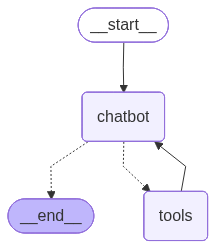

In [15]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition, ToolNode
from typing import TypedDict, Annotated, List
from langgraph.graph.message import add_messages

# State
class State(TypedDict):
    messages: Annotated[List, add_messages]

SYSTEM_PROMPT = """
[상황]
당신은 20년차 건설현장 안전 규정 전문가입니다.
당신은 50억 미만 중소규모 공사현장의 현장소장에게 안전에 관한 조언을 해주어야 합니다.
현장소장은 안전에 대해서 전문가가 아니기 때문에, 애매한 답변은 피하고, 명확하게 답변하세요.
또한 안전규정집에 근거하지 아니하고 답변을 할 경우, 공사 현장에 혼란을 줄 수 있으니,
안전 관련 질문은 반드시 search_safety_regulation 도구로 검색한 내용만을 참고해서 답변하세요.
질문에 날씨가 포함되는 경우에는 반드시 get_current_weather 도구로 최신 날씨 정보를 가져와서 답변에 반영하세요.
만약 질문에 대한 답변을 하는데 추가적인 정보가 필요하다고 판단되면,
human_assist 도구를 사용해서 사람의 도움을 받아보세요.

[도구 사용 규칙]
- 안전 규정 질문 → search_safety_regulation 사용
- 날씨 질문 → get_current_weather 사용 
- human_assist는 다음 경우에만 사용하세요:
  * 사용자가 명시적으로 담당자 연결을 요청할 때
  * 검색 결과가 없고 법적 판단이 필요한 경우
  * 절대 일반적인 안전 규정 질문에는 사용하지 마세요

[응답 규칙]
검색 결과에 없는 내용은 추론하지 말고 '해당 내용을 찾을 수 없습니다'라고 답하세요.
핵심적인 내용 위주로 간결하게 답변하세요.
항상 답변 마지막에 참조한 출처를 표시하세요.
"""

def chatbot(state: State):
    messages = [{"role": "system", "content": SYSTEM_PROMPT}] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)

builder = StateGraph(State)
builder.add_node('chatbot', chatbot)
builder.add_node('tools', tool_node)

builder.add_edge(START, 'chatbot')
builder.add_conditional_edges('chatbot', tools_condition)
builder.add_edge('tools', 'chatbot')

graph = builder.compile(checkpointer=checkpointer)
graph

In [16]:
from langgraph.types import Command

config = {"configurable": {"thread_id": "1"}}

def chat(user_input):
    try:
        result = graph.invoke(
            {"messages": [{"role": "user", "content": user_input}]},
            config=config
        )
        
        # interrupt 발생 시 처리
        if "__interrupt__" in result:
            interrupt_data = result["__interrupt__"][0].value
            print(f"\n[추가 정보 필요] {interrupt_data['query']}")
            human_input = input("답변을 입력하세요: ")
            
            result = graph.invoke(
                Command(resume={"data": human_input}),
                config=config
            )
        
        print(result["messages"][-1].content)

    except Exception as e:
        print(f"에러 발생: {e}")
        print("새 대화를 시작합니다.")
        # thread_id 초기화
        config["configurable"]["thread_id"] = str(int(config["configurable"]["thread_id"]) + 1)

In [17]:
chat("평택에서 공구리치려고 하는데 비가 너무 많이 오네, 작업해도 되나?")

평택의 최신 기상 정보를 찾는 데 오류가 발생했습니다. 현재 비가 많이 오는 상태라면 안전사고 위험이 높으므로, 작업을 중단하는 것이 안전합니다. 특히 비오는 날은 미끄럼, 전기 위험, 구조물 붕괴 위험이 있으니 작업을 하지 말고, 기상이 안정될 때까지 기다리시기 바랍니다.

정확한 현장 작업 가능 여부는 반드시 기상 상황을 다시 확인 후 결정하시고, 관련 안전규정을 따르십시오.

추가로 평택의 정확한 날씨 정보를 조회할 수 있도록 기상 정보를 다시 시도하거나 현지 기상청 정보를 참고하시길 권장드립니다. 

참조: 건설현장 일반 안전수칙 (검색 기준)


In [18]:
chat("서울에서 철근 공사를 좀 하려고 하는데, 이 정도 비면 해도 괜찮나?")

서울의 최신 기상정보는 시스템상에서 확인되지 않았으나, 안전규정에 따르면 다음과 같은 사항을 참고하시기 바랍니다.

철근공사를 비오는 날 진행할 경우 다음과 같은 안전조치를 반드시 준수해야 합니다:

1. 폭우, 강풍 등 악천후 시에는 작업을 중지해야 합니다.
2. 비에 의한 미끄럼, 감전사고 위험이 높으므로 전기설비, 가설배선의 방수 및 접지 상태를 철저히 점검해야 합니다.
3. 젖은 상태에서 전기기계·기구를 취급하지 않도록 주의해야 하며 누전차단기 설치 및 작동 여부를 확인해야 합니다.
4. 낙뢰 발생 시에는 즉시 작업을 중단하고 안전한 장소로 대피해야 합니다.
5. 작업장 주변 배수로를 정비하고, 물 고임이나 침수를 방지해야 합니다.
6. 굴착면 붕괴, 토사 유실을 예방하기 위해 비닐 덮개 설치, 흙막이 지보공 등의 조치를 해야 합니다.

결론적으로, 비가 많이 오고 있는 상태에서는 철근공사를 포함한 건설작업을 중단하는 것이 안전하며, 기상 상황이 안정된 후에 작업을 재개해야 합니다.

참조: 
- C-113-2020 취약시기 건설현장 안전작업지침
- C-6-2004 콘크리트공사 표준안전작업지침 (철근공사 관련)
- 산업안전보건법 및 관련 기술지침


In [19]:
test_jargon_queries = [
    "아시바 위에서 덴죠오 작업할 때 하이바 꼭 써야 합니까?",
    "공구리 타설 전에 와꾸 상태 확인해야 하나요?",
    "기리바리 설치할 때 도도메 작업은 어떻게 해야 합니까?",
    "아시바 해체할 때 바라시 순서랑 안전 규정이 어떻게 됩니까?",
    "겐바에서 렝가 쌓을 때 메지 두께 기준이 있습니까?",
    "하리 밑에서 공구리 타설할 때 세끼이다 고정 방법이 어떻게 됩니까?",
    "노보리 삼바시에서 덴죠오 작업 시 안전대 규정이 있습니까?",
    "도도메 설치하고 기리바리 받침 공구리 강도 기준이 어떻게 됩니까?",
    "하시라 세울 때 와꾸 고정하는 보도 규격이 있습니까?",
    "아시바 설치 후 겐바 안전점검은 얼마나 자주 해야 합니까?",
]

for query in test_jargon_queries:
    print(f"\n{'='*50}")
    print(f"질문: {query}")
    print(f"{'='*50}")
    chat(query)


질문: 아시바 위에서 덴죠오 작업할 때 하이바 꼭 써야 합니까?
[쿼리 재작성] 아시바 덴죠오 작업 안전대 하이바 착용 의무 → 비계 천장 작업 안전모 착용 의무
아시바 위에서 덴죠오 작업 시 안전을 위해 반드시 하이바(안전대)를 착용해야 합니다. 

- 작업자는 작업계획서 수립 시 안전대 착용과 작업용 로프, 구명줄 고정 여부를 철저히 관리해야 하며, 안전대 부착 설비는 작업대 이외의 곳에 설치되어야 합니다.
- 작업 전 안전모와 함께 안전대를 착용하고, 안전대를 구명줄(안전대 부착설비)에 반드시 부착해야 합니다.
- 작업 중 안전대의 추락 방지용 구명줄 결속 여부를 수시로 확인하고, 2개 이상의 견고한 고정점에 안전로프와 구명줄을 나누어 결속하여야 합니다.
- 악천후 시에는 작업을 중지해야 하며, 작업 시 작업대의 견고성, 로프 상태, 결속 상태 등을 사전에 점검해야 합니다.

즉, 아시바 위 덴죠오 작업은 추락 위험이 크므로 하이바(안전대) 착용이 법적 의무이며, 이를 철저히 준수해야 추락사고를 예방할 수 있습니다.

참조: D-C-13-2026 외벽도장보수공사 안전작업 기술지원규정, D-C-7-2026 비계 구조 및 안전작업 기술지원규정

질문: 공구리 타설 전에 와꾸 상태 확인해야 하나요?
[쿼리 재작성] 공구리 타설 와꾸 상태 확인 안전 규정 → 콘크리트 타설 틀 상태 확인 안전 규정
공구리(거푸집) 타설 전에 반드시 와꾸 상태를 확인해야 합니다.

- 콘크리트 타설 중 거푸집 및 거푸집 동바리의 이상 유무를 반드시 점검하고, 이상이 발견되면 즉시 안전 조치를 해야 합니다.
- 타설 전에 가설물(와꾸 포함)의 설치 상태를 점검하여 견고함과 안전성을 확보한 후 작업을 진행해야 합니다.
- 이상 상태가 있으면 보수 또는 보강 작업을 하고 나서 타설해야 하며, 타설 중에도 이상 여부를 감시하는 감시자를 배치해야 합니다.

즉, 와꾸 상태 확인은 공구리 타설 작업의 기본 안전조치이며, 이를 소홀히 하면 붕괴 등 사고 위험이 크므로 반드시 확인 후 작업해야

In [20]:
test_typo_queries = [
    "아시발 위에서 덴조 작업할 때 하이바 꼭 써야 합니까?",
    "공구리 타셜 전에 와꾸 상태 확인해야 하나요?",
    "기리바리 설치할 때 도도매 작업은 어떻게 해야 합니까?",
    "하리 밑에서 공구리 타설할 때 세끼이다 고정 방법이 어떻게 됩니까?",
    "아시바 설치 후 겐빠 안전점검은 얼마나 자주 해야 합니까?",
]

for i, query in enumerate(test_typo_queries):
    config["configurable"]["thread_id"] = str(i + 200)
    print(f"\n{'='*50}")
    print(f"질문: {query}")
    print(f"{'='*50}")
    chat(query)


질문: 아시발 위에서 덴조 작업할 때 하이바 꼭 써야 합니까?
[쿼리 재작성] 덴조 작업 시 하이바 착용 의무 → 덴조 작업 시 헬멧 착용 의무
덴조 작업 시 별도로 '하이바 착용'에 관한 직접적인 의무 조항은 안전규정 문서에서 찾을 수 없습니다. 다만, 작업 발판 위에서 높은 곳에서 작업할 경우에는 비계나 작업발판 설치가 필수이며, 추락 방지를 위해 안전대(하네스)를 포함한 개인보호구 착용이 요구됩니다. 따라서 덴조 작업 시 추락 위험이 있다면 안전모, 안전대 등 필수 개인 보호구를 반드시 착용해야 하며, 하이바는 추락 방지 안전대의 범주에 포함되는 것이 일반적입니다.

요약하면, 덴조 작업의 추락 위험이 있을 때는 작업 안전을 위해 반드시 안전대(하네스) 등 추락 방지 장비를 착용해야 하며, 하이바도 이에 포함될 수 있으므로 반드시 안전장비 착용 지침을 준수하시기 바랍니다.

참조: C-66-2016 내장공사의 안전보건작업 지침 (천장공사 안전관리사항)

질문: 공구리 타셜 전에 와꾸 상태 확인해야 하나요?
[쿼리 재작성] 공구리 타설 전 와꾸 상태 확인 여부 → 공구리 타설 전 틀 상태 확인 여부
공구리(거푸집 및 동바리) 타설 전에 반드시 와꾸 상태를 포함한 거푸집 및 동바리의 변형·변위, 침하 유무 등을 점검하고 이상이 있으면 보수·보강해야 합니다. 또한 콘크리트 타설 전 데크플레이트와 철골 보와의 접합부 시공상태, 데크플레이트 정렬상태와 연결상태를 확인하는 세밀한 사전검사를 실시해야 하며, 데크플레이트 양 끝 지지물은 견고하게 고정되어 있어야 합니다.

타설 중에는 거푸집 및 동바리의 변형, 변위가 발생하지 않도록 감시자를 배치하여 이상 발생 시 즉시 작업을 중지하고 근로자를 대피시키는 등 안전조치를 해야 합니다.

요약:  
- 콘크리트(공구리) 타설 전 와꾸 상태 점검 필수  
- 변형·변위 및 침하 유무 확인 후 이상 시 보수·보강  
- 데크플레이트 시공상태, 지지물 고정 상태 검사  
- 타설 중 지속 감시 및 이상 시 즉시 작업 중지 및